# Évaluation CL — DBSCAN — Dataset CWRU Bearing — by_fault_type

| Champ | Valeur |
|-------|--------|
| **Modèle** | DBSCAN detector (non-supervisé, core points cumulés par tâche) |
| **Dataset** | CWRU Bearing Dataset (Case Western Reserve University) |
| **Scénario** | by_fault_type : Ball → Inner Race → Outer Race (3 tâches) |
| **Expérience** | exp_079_dbscan_cwru_by_fault_type — voir experiments/exp_079_dbscan_cwru_by_fault_type/config_snapshot.yaml |
| **Sprint** | 12 — S12-07 |

> **Stratégie CL** : Accumulation des core points DBSCAN — mémoire croissante
> **Gap 1** : Validation CL sur données réelles de roulements (CWRU — benchmark académique reconnu).
> **Gap 2** : RAM mesurée vs budget STM32N6 ≤ 64 Ko.

```bash
jupyter nbconvert --to notebook --execute \
    notebooks/cl_eval/cwru_by_fault_type/dbscan.ipynb \
    --output /tmp/dbscan_cwru_fault_type_executed.ipynb --ExecutePreprocessor.timeout=300
```

In [1]:
# Section 1 — Setup & imports
import json
import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display

# --- CWD navigation : notebook 3 niveaux de profondeur ---
_cwd = Path(".").resolve()
if _cwd.name == "cwru_by_fault_type":
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == "cl_eval":
    os.chdir(_cwd.parent.parent)
elif _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.plots import (
    plot_accuracy_matrix,
    plot_forgetting_curve,
    save_figure,
)

# --- Chemins ---
EXP_DIR     = REPO_ROOT / "experiments/exp_079_dbscan_cwru_by_fault_type/results"
FIGURES_DIR = REPO_ROOT / "notebooks/figures/cl_evaluation/dbscan/cwru/by_fault_type"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_DIR = REPO_ROOT / "experiments/exp_073_dbscan_cwru_single_task/results"
CSV_PATH     = REPO_ROOT / "data/raw/CWRU Bearing Dataset/feature_time_48k_2048_load_1.csv"

# --- Constantes ---
TASK_NAMES    = ["Ball", "Inner Race", "Outer Race"]
MODEL_NAME    = "DBSCAN"
DATA_AVAILABLE = CSV_PATH.exists()

print(f"REPO_ROOT    : {REPO_ROOT}")
print(f"EXP_DIR      : {EXP_DIR}")
print(f"FIGURES_DIR  : {FIGURES_DIR}")
print(f"Data CSV     : {DATA_AVAILABLE}")
print(f"Date         : {datetime.now():%Y-%m-%d %H:%M}")

REPO_ROOT    : /home/leonard/Documents/ENAC/cl-embedded
EXP_DIR      : /home/leonard/Documents/ENAC/cl-embedded/experiments/exp_079_dbscan_cwru_by_fault_type/results
FIGURES_DIR  : /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/dbscan/cwru/by_fault_type
Data CSV     : True
Date         : 2026-05-13 13:10


In [2]:
# Section 2 — Chargement des résultats exp_079_dbscan_cwru_by_fault_type

metrics_path = EXP_DIR / "metrics_cl.json"
metrics = json.loads(metrics_path.read_text())
# acc_matrix embarquée dans metrics_cl.json (liste 3×3)

# acc_matrix : liste 3×3 avec null → NaN
raw_mat = metrics["acc_matrix"]
acc_matrix_np = np.array(
    [[v if v is not None else np.nan for v in row] for row in raw_mat],
    dtype=float,
)

aa    = metrics["acc_final"]
af    = metrics["avg_forgetting"]
bwt   = metrics["backward_transfer"]
per_task_acc = metrics["per_task_acc"]
ram_b = metrics["ram_peak_bytes"]
lat   = metrics["inference_latency_ms"]
n_par = metrics["n_params"]

print("=" * 58)
print(f"  Modèle         : DBSCAN")
print(f"  AA             = {aa:.4f}")
print(f"  AF             = {af:.4f}")
print(f"  BWT            = {bwt:+.4f}")
print(f"  per_task_acc   = {[round(v, 4) for v in per_task_acc]}")
print(f"  RAM peak       = {ram_b} B ({ram_b/1024:.2f} Ko)")
print(f"  Latence        = {lat:.5f} ms")
print(f"  n_params       = {n_par}")
print(f"  Budget 64 Ko   : {'OK' if ram_b <= 65536 else 'DEPASSE'}")
print("=" * 58)
print("\nMatrice acc (3×3) :")
print(acc_matrix_np)

  Modèle         : DBSCAN
  AA             = 0.1255
  AF             = 0.0455
  BWT            = -0.0455
  per_task_acc   = [0.1039, 0.1039, 0.1688]
  RAM peak       = 16788 B (16.39 Ko)
  Latence        = 0.12908 ms
  n_params       = 1116
  Budget 64 Ko   : OK

Matrice acc (3×3) :
[[0.16883117        nan        nan]
 [0.1038961  0.12987013        nan]
 [0.1038961  0.1038961  0.16883117]]


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/dbscan/cwru/by_fault_type/accuracy_matrix.png


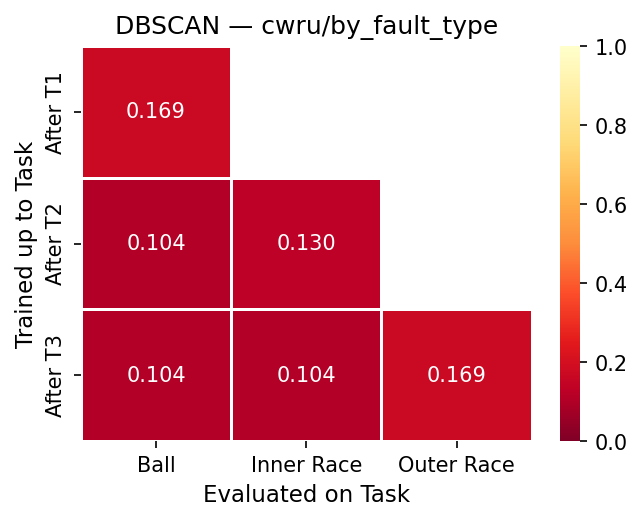

In [3]:
# Section 3 — Matrice d'accuracy (heatmap)
# acc_matrix_np[i, j] = accuracy sur tâche j après entraînement sur tâche i
# Triangle supérieur = NaN (tâche pas encore vue)

fig = plot_accuracy_matrix(
    acc_matrix_np,
    task_names=TASK_NAMES,
    title=f"{MODEL_NAME} — cwru/by_fault_type",
)
save_figure(fig, FIGURES_DIR / "accuracy_matrix.png")
display(Image(str(FIGURES_DIR / "accuracy_matrix.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/dbscan/cwru/by_fault_type/per_task_accuracy_bar.png


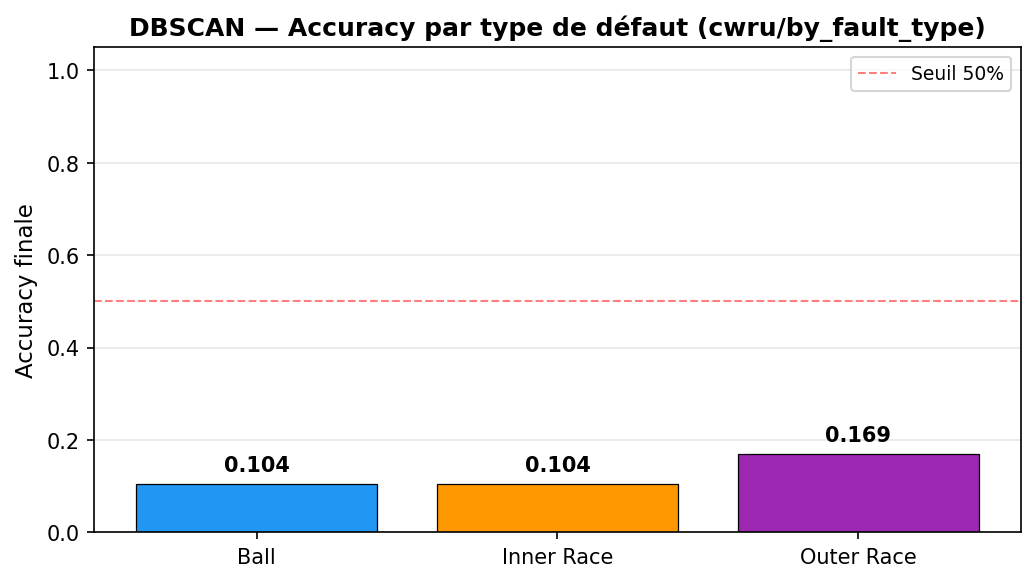

In [4]:
# Section 4 — Barplot accuracy finale par tâche (Ball / Inner Race / Outer Race)

TASK_COLORS = ["#2196F3", "#FF9800", "#9C27B0"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(TASK_NAMES, per_task_acc, color=TASK_COLORS, edgecolor="black", linewidth=0.6)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy finale", fontsize=11)
ax.set_title(f"{MODEL_NAME} — Accuracy par type de défaut (cwru/by_fault_type)", fontsize=12, fontweight="bold")
ax.axhline(y=0.5, color="red", linestyle="--", linewidth=1, alpha=0.5, label="Seuil 50%")

for bar, val in zip(bars, per_task_acc):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        min(val + 0.02, 1.0),
        f"{val:.3f}",
        ha="center", va="bottom", fontsize=10, fontweight="bold",
    )

ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
save_figure(fig, FIGURES_DIR / "per_task_accuracy_bar.png")
display(Image(str(FIGURES_DIR / "per_task_accuracy_bar.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/dbscan/cwru/by_fault_type/forgetting_curve.png


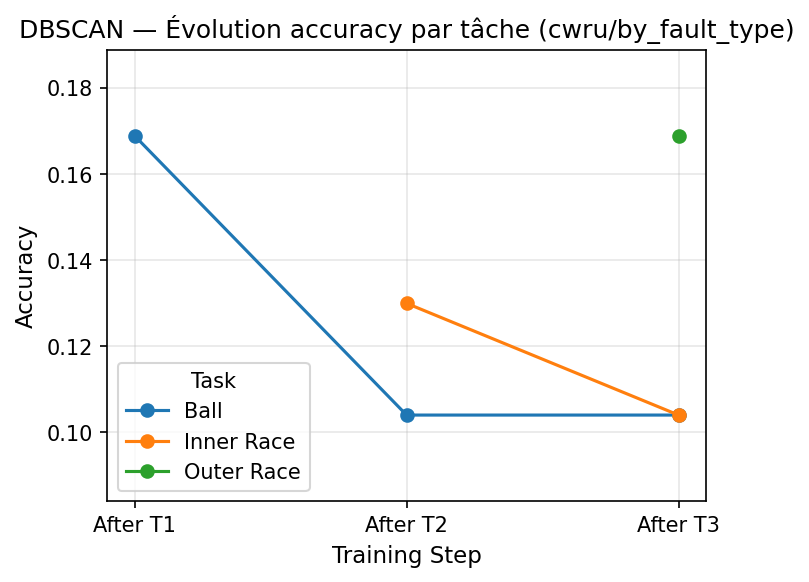

In [5]:
# Section 5 — Courbe d'oubli par tâche
# Montre l'évolution de l'accuracy sur les tâches passées au fil de l'entraînement

fig = plot_forgetting_curve(
    acc_matrix_np,
    task_names=TASK_NAMES,
    title=f"{MODEL_NAME} — Évolution accuracy par tâche (cwru/by_fault_type)",
)
save_figure(fig, FIGURES_DIR / "forgetting_curve.png")
display(Image(str(FIGURES_DIR / "forgetting_curve.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/dbscan/cwru/by_fault_type/ram_vs_budget.png


/tmp/ipykernel_49857/2463783482.py:31: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/plots.py:921: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.savefig(path, dpi=dpi, bbox_inches="tight")


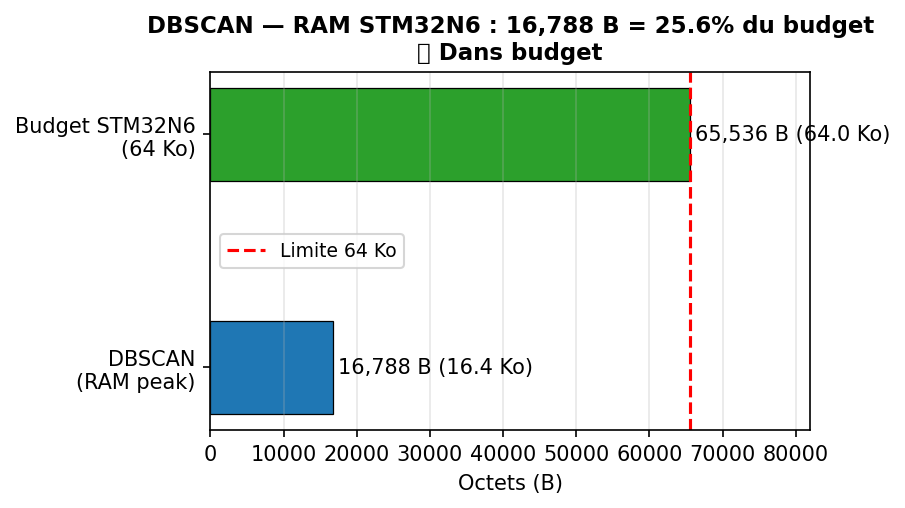

In [6]:
# Section 6 — Profil mémoire : RAM peak vs budget STM32N6 (64 Ko)

RAM_BUDGET = 65_536  # bytes = 64 Ko

fig, ax = plt.subplots(figsize=(6, 3.5))

labels  = [f"{MODEL_NAME}\n(RAM peak)", "Budget STM32N6\n(64 Ko)"]
values  = [ram_b, RAM_BUDGET]
colors  = ["#1f77b4" if ram_b <= RAM_BUDGET else "#d62728", "#2ca02c"]

bars = ax.barh(labels, values, color=colors, edgecolor="black", linewidth=0.6, height=0.4)
ax.axvline(x=RAM_BUDGET, color="red", linestyle="--", linewidth=1.5, label="Limite 64 Ko")

for bar, val in zip(bars, values):
    ax.text(
        val + RAM_BUDGET * 0.01, bar.get_y() + bar.get_height() / 2,
        f"{val:,} B ({val/1024:.1f} Ko)",
        va="center", ha="left", fontsize=10,
    )

pct = ram_b / RAM_BUDGET * 100
status = "✅ Dans budget" if ram_b <= RAM_BUDGET else "❌ Dépasse budget"
ax.set_title(
    f"{MODEL_NAME} — RAM STM32N6 : {ram_b:,} B = {pct:.1f}% du budget\n{status}",
    fontsize=11, fontweight="bold",
)
ax.set_xlabel("Octets (B)", fontsize=10)
ax.set_xlim(0, max(RAM_BUDGET, ram_b) * 1.25)
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
save_figure(fig, FIGURES_DIR / "ram_vs_budget.png")
display(Image(str(FIGURES_DIR / "ram_vs_budget.png")))

### Résultats finaux — DBSCAN — cwru/by_fault_type (exp_079_dbscan_cwru_by_fault_type)


| Métrique | Valeur CL | Baseline single-task |
|----------|-----------|---------------------|
| **AA (avg accuracy)** | 0.1255 | 0.1457 |
| **AF (avg forgetting)** | 0.0455 | — |
| **BWT** | -0.0455 | — |
| **RAM peak** | 16,788 B (16.39 Ko) | 118,468 B (115.69 Ko) |
| **Latence** | 0.12908 ms | 0.23158 ms |
| **n_params** | 1116 | 11286 |
| **Budget 64 Ko** | ✅ | ❌ |


  Critères d'acceptation (S12-07)
  [OK] accuracy_matrix.png
  [OK] per_task_accuracy_bar.png
  [OK] forgetting_curve.png
  [OK] ram_vs_budget.png
  [OK] summary_table.png

  [OK] RAM = 16788 B (budget ≤ 65 536 B)
  [OK] Latence = 0.12908 ms (contrainte ≤ 100 ms)
[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/dbscan/cwru/by_fault_type/summary_table.png


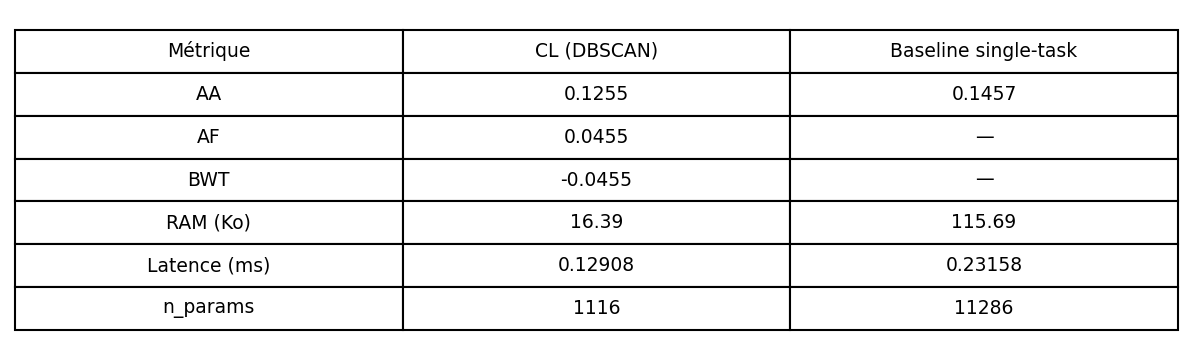

In [7]:
# Section 7 — Tableau récapitulatif + comparaison baseline single-task (exp_073_dbscan_cwru_single_task)

baseline_path = BASELINE_DIR / "metrics_single_task.json"
if baseline_path.exists():
    baseline = json.loads(baseline_path.read_text())
    acc_st  = baseline.get("accuracy") or baseline.get("acc_final", float("nan"))
    ram_st  = baseline.get("ram_peak_bytes", 0)
    lat_st  = baseline.get("inference_latency_ms", 0.0)
    n_par_st = baseline.get("n_params", 0)
else:
    display(Markdown("> ⚠️ Baseline exp_073_dbscan_cwru_single_task non disponible."))
    acc_st = float("nan")
    ram_st = ram_b
    lat_st = lat
    n_par_st = n_par

display(Markdown(f"### Résultats finaux — {MODEL_NAME} — cwru/by_fault_type (exp_079_dbscan_cwru_by_fault_type)"))

table_md = f"""
| Métrique | Valeur CL | Baseline single-task |
|----------|-----------|---------------------|
| **AA (avg accuracy)** | {aa:.4f} | {acc_st:.4f} |
| **AF (avg forgetting)** | {af:.4f} | — |
| **BWT** | {bwt:+.4f} | — |
| **RAM peak** | {ram_b:,} B ({ram_b/1024:.2f} Ko) | {ram_st:,} B ({ram_st/1024:.2f} Ko) |
| **Latence** | {lat:.5f} ms | {lat_st:.5f} ms |
| **n_params** | {n_par} | {n_par_st} |
| **Budget 64 Ko** | {'✅' if ram_b <= 65536 else '❌'} | {'✅' if ram_st <= 65536 else '❌'} |
"""
display(Markdown(table_md))

# Vérification critères d'acceptation (S12-07)
print("=" * 58)
print("  Critères d'acceptation (S12-07)")
print("=" * 58)
expected_figs = [
    "accuracy_matrix.png",
    "per_task_accuracy_bar.png",
    "forgetting_curve.png",
    "ram_vs_budget.png",
    "summary_table.png",
]
for fig_name in expected_figs:
    p = FIGURES_DIR / fig_name
    status = "OK" if p.exists() else "MANQUANTE"
    print(f"  [{status}] {fig_name}")

print()
print(f"  [{'OK' if ram_b <= 65536 else 'FAIL'}] RAM = {ram_b} B (budget ≤ 65 536 B)")
print(f"  [{'OK' if lat < 100.0 else 'WARN'}] Latence = {lat:.5f} ms (contrainte ≤ 100 ms)")

# --- Sauvegarde du tableau récapitulatif ---
fig_table, ax_t = plt.subplots(figsize=(8, 2.5))
ax_t.axis("off")
col_labels = ["Métrique", "CL (DBSCAN)", "Baseline single-task"]
row_data = [
    ["AA", f"{aa:.4f}", f"{acc_st:.4f}"],
    ["AF", f"{af:.4f}", "—"],
    ["BWT", f"{bwt:+.4f}", "—"],
    ["RAM (Ko)", f"{ram_b/1024:.2f}", f"{ram_st/1024:.2f}"],
    ["Latence (ms)", f"{lat:.5f}", f"{lat_st:.5f}"],
    ["n_params", str(n_par), str(n_par_st)],
]
tbl = ax_t.table(
    cellText=row_data,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.5)
fig_table.tight_layout()
save_figure(fig_table, FIGURES_DIR / "summary_table.png")
display(Image(str(FIGURES_DIR / "summary_table.png")))